In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [2]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import VarianceThreshold
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from PMAPUtil import *

/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
# death_at_disch hypothermia 
def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('PMAP_Predictors4.csv')

    top_corr = pd.read_csv('top_correlations.csv')
    columns_to_drop = top_corr[top_corr['hypothermia'].abs() > 0.7]['Unnamed: 0'].tolist()
    
    # Preprocessing
    myFilter = (myPredictorsDf['first_mGCS_time'] != myPredictorsDf['last_mGCS_time']) 
    myPredictorsDf.loc[myPredictorsDf['death_at_disch'] == 1, 'last_mGCS'] = 1
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'last_mGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.first_mGCS != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x and 'dx_' == x[0:3]]

    # Get output data
    myXValue = myPredictorsDf.drop(columns=  myColumns + ['first_mGCS', 'last_mGCS_time', 'first_mGCS_time', 'LastMGCSPositive', 'last_mGCS', 'death_at_disch'])
    myXValue = myXValue
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [4]:
myTreatmentColumn = 'hypothermia'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', 
                                                                         aTreatmentColumn = myTreatmentColumn, 
                                                                         aSkipTemp = True) 

In [5]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myBinaryColumns  = ['bin__' + x for x in myBinaryColumns]
    myCovariates = getCovariatePreprocessor(['keep__bin__' + myTreatmentColumn])
    myCovariates.set_output(transform="pandas")
    myVariance = getVariancePreprocessor(['bin__' + myTreatmentColumn])
    myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor),  ('variance', myVariance), ('imputer', myImputer), ('covariates', myCovariates)]

In [6]:
X_train = X_train.loc[:, X_train.isnull().mean() < 0.9]
X_test = X_test[X_train.columns]

In [7]:
X_test.head(1)

,gender,ed_visit_yn,age,flo_first_bp_systolic,flo_first_r_ed_acuity,flo_first_bp_diastolic,flo_first_jhm_r_ed_etriage_a,flo_first_jhm_r_ed_etriage_c,flo_first_jhm_r_ed_etriage_im,flo_first_jhm_r_ed_etriage_sc,...,"dx_wounds,_multiple",asystole,cardiac arrest with successful resuscitation,cardiopulmonary arrest,death due to cardiac arrest,traumatic cardiac arrest,pea,cardiopulmonary arrest w/ resuscitation,VF,hypothermia
299,1,1,63,100.0,1.0,64.0,61.89,NaN,46.9,0.0,...,0.0,0,0,0,0,0,0,0,0,1


In [ ]:
DefaultGrid = [
    {
        'clf': [XGBClassifier(eval_metric='logloss')],
        'clf__n_estimators': [5, 25, 100, 500], 
        'clf__max_depth': [5, 10, 50, 100]
    },
    # {
    #     'clf': [XGBClassifier(eval_metric='logloss')],
    #     'clf__n_estimators': [50], 
    #     'clf__max_depth': [10]
    # }
    # {
    #     'clf': [DecisionTreeClassifier()],
    #     'clf__max_depth': [2, 5, 20, 50, None],
    #     'clf__class_weight': [None, 'balanced']
    # },
    # {
    #     'clf': [LogisticRegression(), SVC(probability=True)],
    #     'clf__C': [0.01, 0.1, 1, 10, 100]
    # }
    # {
    #     'clf': [KerasClassifier(model=build_model, epochs=30, batch_size=32, verbose=1)]
    # }
]
def gridSearchKFoldClassification(X_train, X_test, y_train, y_test, aScore = 'roc_auc', aGrid = DefaultGrid):
    kf = StratifiedKFold(n_splits=5, shuffle=True)
    myPipelineSteps = getDefaultPipelineSteps(X_train = X_train)
    myPipelineSteps.append(('clf', XGBClassifier()))
    myPipeline = Pipeline(myPipelineSteps)
    myGridSearchCv = GridSearchCV(myPipeline, aGrid, cv=kf, scoring=aScore, n_jobs=-1, verbose=3)
    myGridSearchCv.fit(X_train, y_train)
    myBestModel = myGridSearchCv.best_estimator_
    y_pred_proba = myBestModel.predict_proba(X_test)[:, 1]
    y_pred = myBestModel.predict(X_test)
    print(f'Best parameters: {myGridSearchCv.best_params_}')
    print(f'Best cross val {aScore} score: {myGridSearchCv.best_score_:.4f}')
    print(f'Area under the receiver operating curve on test set is {roc_auc_score(y_test, y_pred_proba):.4f}')
    print(f'Accuracy score on test set is {accuracy_score(y_test, y_pred):.4f}')
    return myGridSearchCv
myGridSearchCv = gridSearchKFoldClassification(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='roc_auc', aGrid = DefaultGrid)
myBestModel = myGridSearchCv.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits


/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain f

[CV 5/5] END clf=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...), clf__max_depth=5, clf__n_estimators=100;, score=0.750 total time=  25.0s
[CV 5/5] END clf=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
       

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

y_pred_probs = myBestModel.predict_proba(X_test)[:, 1]

def bootstrap_auc_ci(y_true, y_pred_proba, n_bootstraps=1000, ci=95, random_seed=42):
    rng = np.random.RandomState(random_seed)
    n = len(y_true)
    bootstrapped_scores = []
    
    for _ in range(n_bootstraps):
        # Sample with replacement
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true[indices])) < 2:
            # We need at least one positive and one negative sample
            continue
        score = roc_auc_score(y_true[indices], y_pred_proba[indices])
        bootstrapped_scores.append(score)
    
    sorted_scores = np.sort(bootstrapped_scores)
    lower_bound = np.percentile(sorted_scores, (100 - ci) / 2)
    upper_bound = np.percentile(sorted_scores, 100 - (100 - ci) / 2)
    
    return lower_bound, upper_bound, sorted_scores

# Example usage
# y_true = np.array([...])
# y_pred_proba = np.array([...])

ci_lower, ci_upper, auc_scores = bootstrap_auc_ci(y_test.to_numpy(), y_pred_probs)
print(f"95% CI for AUC: [{ci_lower:.3f}, {ci_upper:.3f}]")


In [ ]:
myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps.covariates.get_feature_names_out()), X_train, y_train)

In [ ]:
myFeatureImportancesDf[myFeatureImportancesDf.Feature == 'keep__keep__bin__hypothermia']

In [ ]:
myX = pd.concat([X_train.reset_index().drop(columns='index'), X_test.reset_index().drop(columns='index')])
myY = pd.concat([y_train.reset_index().drop(columns='index'), y_test.reset_index().drop(columns='index')])

Optimization terminated successfully.
         Current function value: 0.545877
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.545758
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.30888372777326367
p-value: 0.5783659836702506
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                 1292
Model:                          Logit   Df Residuals:                     1289
Method:                           MLE   Df Model:                            2
Date:                Mon, 28 Apr 2025   Pseudo R-squ.:                 0.01874
Time:                        08:15:44   Log-Likelihood:                -705.27
converged:                       True   LL-Null:                       -718.75
Covariance Type:            nonrobust   LLR p-value:                 1.410e-06
                     

0.5783659836702506

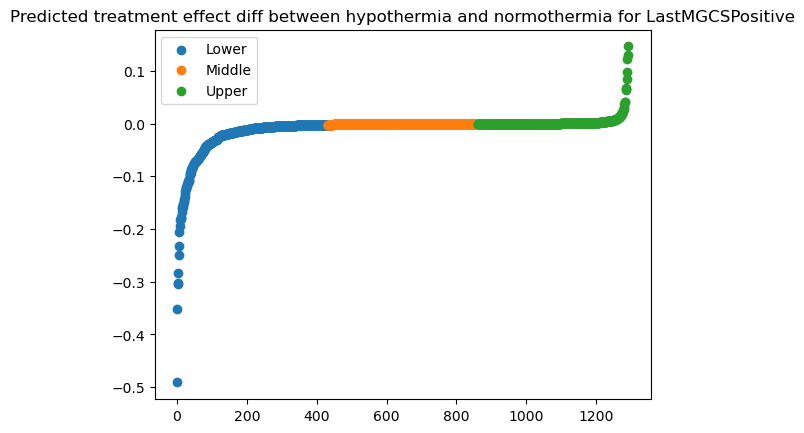

In [48]:
getTreatmentEffectDiff(aX = myX.reset_index().drop(columns='index'), aY = myY.reset_index().drop(columns='index'), aModel = myBestModel, \
                       aCategory = 'LastMGCSPositive', aGroup = 'hypothermia', aUseNeuralNetwork = False, aByGroup = False)

In [ ]:
getTreatmentEffectDiff(aX = myX.reset_index().drop(columns='index'), aY = myY.reset_index().drop(columns='index'), aModel = myBestModel, \
                       aCategory = 'death_at_disch', aGroup = 'hypothermia', aUseNeuralNetwork = False, aByGroup = False)